## _Track Building after Edge Classification_


- Wrangler Algorithm
- Connected Components (see `trkx_from_gnn.py`)

In [1]:
import sys, os, glob, yaml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
from tqdm import tqdm
import trackml.dataset

In [4]:
import torch
import pytorch_lightning as pl
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import itertools

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [6]:
os.environ['EXATRKX_DATA'] = os.path.abspath(os.curdir)

### _(1) - Connected-component Labeling (CCL)_

Connected-component Labeling (CCL) or connected-component analysis (CCA) is an algorithmic application of graph theory, where subsets of connected components are uniquely labeled based on a given **heuristic** (DBSCAN ???). Connected-component labeling is not to be confused with segmentation.

- access `src/cc`

In [7]:
from src import tracks_from_cc

In [8]:
# Read Event from the Testset
inputdir="run/gnn_evaluation/test"
outputdir="run/stt2_trkx/trkx_from_cc"
os.makedirs(outputdir, exist_ok=True)

In [9]:
all_files = glob.glob(os.path.join(inputdir, "*"))
all_files = sorted(all_files)
print("Total Test Events: ", len(all_files))

Total Test Events:  5000


In [10]:
all_files[:10]

['run/gnn_evaluation/test/5000',
 'run/gnn_evaluation/test/5001',
 'run/gnn_evaluation/test/5002',
 'run/gnn_evaluation/test/5003',
 'run/gnn_evaluation/test/5004',
 'run/gnn_evaluation/test/5005',
 'run/gnn_evaluation/test/5006',
 'run/gnn_evaluation/test/5007',
 'run/gnn_evaluation/test/5008',
 'run/gnn_evaluation/test/5009']

In [11]:
# Use One Event
filename = all_files[1]
evtid = int(os.path.basename(filename))
print("evtid: ", evtid)

evtid:  5001


In [12]:
# Get Edge and Edge Score
event = torch.load(filename, map_location=device)
score = event.scores[:event.edge_index.shape[1]]  # score has twice the size of edge_index (flip(0) was used)
senders = event.edge_index[0]
receivers = event.edge_index[1]
hit_id = event.hid

In [13]:
type(score)

torch.Tensor

In [14]:
# Run CCL method
reco_track = tracks_from_cc (hit_id, score, senders, receivers)
torch.save(reco_track, os.path.join(outputdir, "{}".format(evtid)))

/shared/adeel/anaconda3/envs/exatrkx-cpu/lib/python3.8/site-packages/sklearn/neighbors/_base.py:206: EfficiencyWarning: Precomputed sparse input was not sorted by data.
  warnings.warn(


In [15]:
reco_track.head()

,hit_id,track_id
0,222,0
1,171,1
2,16,2
3,42,3
4,67,-1


### _Plot True and Reco Events_

In [16]:
from src.drawing import detector_layout
from src.utils_math import polar_to_cartesian

In [17]:
true_track = event
print(true_track)

Data(x=[171, 3], pid=[171], layers=[171], event_file='/global/cscratch1/sd/aakram/train_all/event0000095001', hid=[171], pt=[171], modulewise_true_edges=[2, 160], layerwise_true_edges=[2, 172], edge_index=[2, 808], y_pid=[808], scores=[1616])


In [18]:
r, phi, ir = true_track.x.T
ir = ir.detach().numpy()*100
x, y = polar_to_cartesian(r.detach().numpy(), phi.detach().numpy())

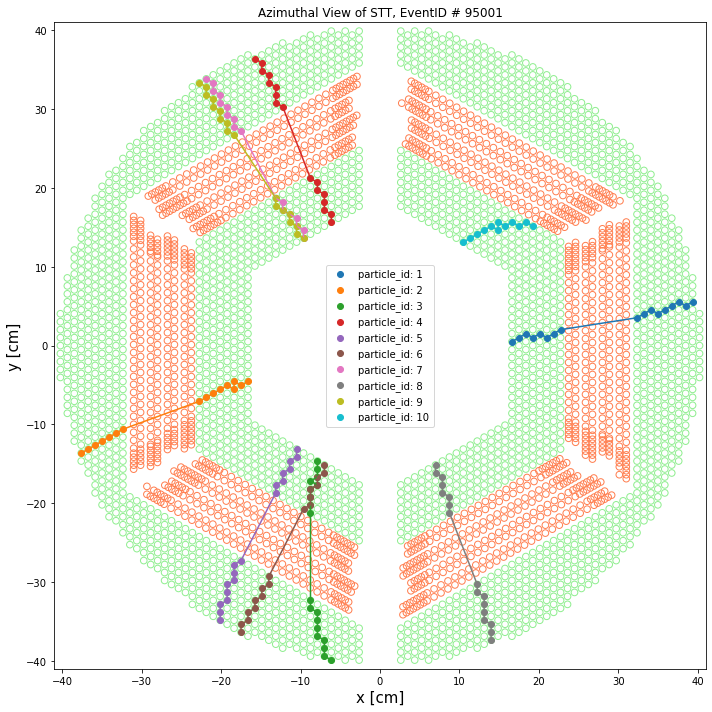

In [19]:
# plot true event
fig, ax = detector_layout(figsize=(10,10))
e_id = int(true_track.event_file[-10:])
p_ids = np.unique(true_track.pid)

for pid in p_ids:
    idx = true_track.pid == pid
    ax.plot(x[idx], y[idx], '-', linewidth=1.5)
    ax.scatter(x[idx], y[idx], label='particle_id: {}'.format(int(pid)))

ax.set_title('Azimuthal View of STT, EventID # {}'.format(e_id))
ax.legend(fontsize=10, loc='best')
fig.tight_layout()
# fig.savefig("true_track.png")

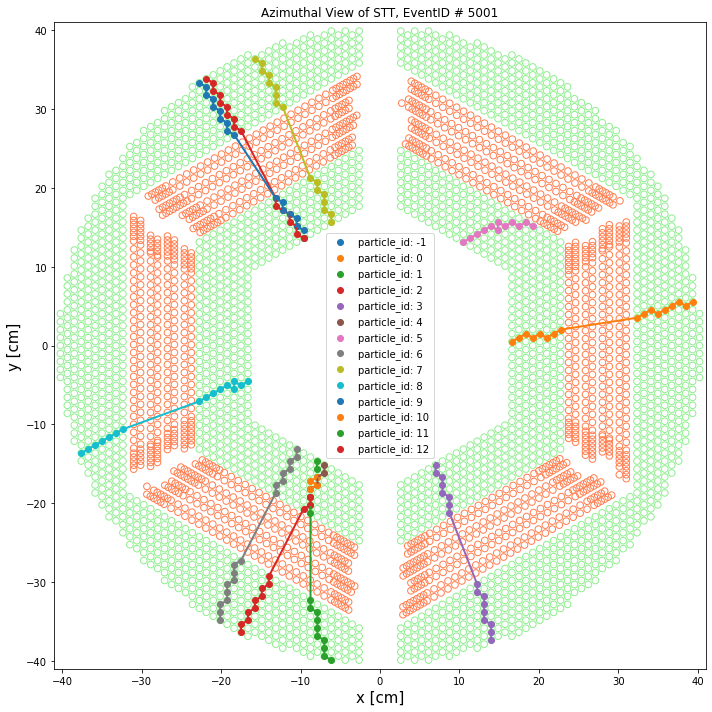

In [20]:
# plot reco event from CCL

# here, (x,y,ir) comes from ture event. but idx is from reco event
fig, ax = detector_layout(figsize=(10,10))
t_ids = np.unique(reco_track.track_id)

for tid in t_ids:
    idx = reco_track.track_id == tid
    ax.plot(x[idx], y[idx], '-', linewidth=2)
    ax.scatter(x[idx], y[idx], label='particle_id: {}'.format(tid))
    
ax.set_title('Azimuthal View of STT, EventID # {}'.format(evtid))
ax.legend(fontsize=10, loc='best')
fig.tight_layout()
# fig.savefig("reco_track.png")

### _(2) - Wrangler Algorithm_

- Wrangle is in NetworkX

Procedure is something like this:

- read testset (`hid, score`)
- convert it, if needed, to NetworkX structure
- call Wrangler from `src/wrangler`


To convert `Torch::Tensor` to `NetworkX::DiGraph()` dast see https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/utils/convert.html